<a href="https://colab.research.google.com/github/spesivan/colab-notes-v2/blob/main/Image_Classification_Using_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
# https://www.youtube.com/watch?v=Rmtr9SY-4VQ

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers, datasets, models
from tensorflow.keras.models import Sequential

In [2]:
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

170498071/170498071 [==============================] - 3s 0us/step


In [4]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)
(50000, 1)
(10000, 1)


In [6]:
y_train = y_train.reshape(-1,)
y_test = y_test.reshape(-1,)

In [7]:
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [8]:
def plot_sample(X, y, index):
    plt.figure(figsize=(15, 2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

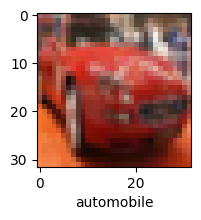

In [9]:
plot_sample(X_train, y_train, 5)

In [10]:
X_train = X_train / 255
X_test = X_test / 255

In [11]:
ann = models.Sequential([
    layers.Flatten(input_shape=(32, 32, 3)),
    layers.Dense(3000, activation='relu'),
    layers.Dense(1000, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann.compile(optimizer='SGD',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

ann.fit(X_train, y_train, epochs=5)

Epoch 1/5
1563/1563 [==============================] - 163s 104ms/step - loss: 1.8125 - accuracy: 0.3537
Epoch 2/5
1563/1563 [==============================] - 167s 107ms/step - loss: 1.6238 - accuracy: 0.4295
Epoch 3/5
1563/1563 [==============================] - 186s 119ms/step - loss: 1.5411 - accuracy: 0.4578
Epoch 4/5
1563/1563 [==============================] - 145s 93ms/step - loss: 1.4830 - accuracy: 0.4780
Epoch 5/5
1563/1563 [==============================] - 151s 96ms/step - loss: 1.4320 - accuracy: 0.4960


In [12]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_pred = ann.predict(X_test)  # Assuming 'ann' is a trained model

# Convert predicted probabilities to class labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Print the classification report
print("Classification report:\n", classification_report(y_test, y_pred_classes))

313/313 [==============================] - 10s 31ms/step
Classification report:
               precision    recall  f1-score   support

           0       0.54      0.48      0.51      1000
           1       0.65      0.50      0.57      1000
           2       0.36      0.34      0.35      1000
           3       0.30      0.46      0.36      1000
           4       0.53      0.29      0.37      1000
           5       0.55      0.18      0.27      1000
           6       0.44      0.66      0.53      1000
           7       0.70      0.40      0.51      1000
           8       0.39      0.83      0.53      1000
           9       0.60      0.47      0.52      1000

    accuracy                           0.46     10000
   macro avg       0.51      0.46      0.45     10000
weighted avg       0.51      0.46      0.45     10000



In [13]:
import seaborn as sbn

In [20]:
#plt.figure(figsize=(14, 7))
#sbn.heatmap(y_pred, annot=True)
#plt.ylabel("Truth")
#plt.xlabel("Prediction")
#plt.title("Confusion matrix")
#plt.show()

In [21]:
cnn = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation="relu", input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(filters=64, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

In [22]:
cnn.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [23]:
cnn.fit(X_train, y_train, epochs=10)

Epoch 1/10
1563/1563 [==============================] - 61s 39ms/step - loss: 1.4804 - accuracy: 0.4677
Epoch 2/10
1563/1563 [==============================] - 59s 37ms/step - loss: 1.1194 - accuracy: 0.6067
Epoch 3/10
1563/1563 [==============================] - 57s 36ms/step - loss: 0.9784 - accuracy: 0.6610
Epoch 4/10
1563/1563 [==============================] - 57s 37ms/step - loss: 0.8994 - accuracy: 0.6884
Epoch 5/10
1563/1563 [==============================] - 60s 38ms/step - loss: 0.8410 - accuracy: 0.7078
Epoch 6/10
1563/1563 [==============================] - 57s 36ms/step - loss: 0.7870 - accuracy: 0.7270
Epoch 7/10
1563/1563 [==============================] - 55s 35ms/step - loss: 0.7423 - accuracy: 0.7432
Epoch 8/10
1563/1563 [==============================] - 57s 37ms/step - loss: 0.7025 - accuracy: 0.7557
Epoch 9/10
1563/1563 [==============================] - 55s 35ms/step - loss: 0.6688 - accuracy: 0.7654
Epoch 10/10
1563/1563 [==============================] - 56s 36m

In [27]:
cnn.evaluate(X_test, y_test)

313/313 [==============================] - 6s 16ms/step - loss: 0.9397 - accuracy: 0.6921


[0.9397256970405579, 0.6920999884605408]

In [28]:
y_pred = cnn.predict(X_test)
y_pred[:5]

313/313 [==============================] - 4s 13ms/step


array([[4.48647770e-04, 1.59846313e-04, 1.42200598e-02, 5.65880001e-01,
        1.45273388e-03, 3.85879695e-01, 2.55282316e-03, 4.52936074e-04,
        2.66895983e-02, 2.26368615e-03],
       [7.56652909e-04, 3.66728067e-01, 9.28571495e-08, 2.23228991e-08,
        4.46467538e-08, 2.51805776e-09, 6.55601013e-08, 4.77280722e-08,
        6.32180691e-01, 3.34403943e-04],
       [4.26840819e-02, 5.53356886e-01, 2.81909364e-03, 2.64752074e-03,
        4.93059983e-04, 6.66405904e-05, 6.43423933e-04, 1.28436572e-04,
        2.67075390e-01, 1.30085602e-01],
       [7.68045068e-01, 1.12914955e-02, 3.65321413e-02, 2.06937245e-03,
        4.02394794e-02, 5.12379265e-05, 7.38459639e-05, 1.12939451e-04,
        1.39970571e-01, 1.61376514e-03],
       [2.45537905e-07, 3.88828448e-06, 5.37205162e-03, 5.21418732e-03,
        6.47560060e-01, 1.06116722e-03, 3.40779036e-01, 3.27345833e-06,
        4.99437010e-06, 1.03431739e-06]], dtype=float32)

In [29]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[5]

6

In [30]:
y_test[5]

6